<a href="https://colab.research.google.com/github/Dhanvanthri007/Liver_Cirrhosis/blob/main/Liver_Cirrhosis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install shap lime scikit-learn pandas matplotlib seaborn ucimlrepo --quiet
print("✅ All libraries installed successfully!")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 17.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
✅ All libraries installed successfully!


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import lime
import lime.lime_tabular
import warnings
warnings.filterwarnings('ignore')

from ucimlrepo import fetch_ucirepo
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder

np.random.seed(42)
shap.initjs()
print("✅ Libraries imported successfully!")


✅ Libraries imported successfully!


In [3]:
cirrhosis = fetch_ucirepo(id=878)

X_raw = cirrhosis.data.features.copy()
y_raw = cirrhosis.data.targets.copy()

df = pd.concat([X_raw, y_raw], axis=1)
print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
df.head()


Dataset shape: (418, 18)

Columns: ['Drug', 'Age', 'Sex', 'Ascites', 'Hepatomegaly', 'Spiders', 'Edema', 'Bilirubin', 'Cholesterol', 'Albumin', 'Copper', 'Alk_Phos', 'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin', 'Stage', 'Status']


,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage,Status
0,D-penicillamine,21464,F,Y,Y,Y,Y,14.5,261,2.60,156,1718.0,137.95,172,190,12.2,4.0,D
1,D-penicillamine,20617,F,N,Y,Y,N,1.1,302,4.14,54,7394.8,113.52,88,221,10.6,3.0,C
2,D-penicillamine,25594,M,N,N,N,S,1.4,176,3.48,210,516.0,96.10,55,151,12.0,4.0,D
3,D-penicillamine,19994,F,N,Y,Y,S,1.8,244,2.54,64,6121.8,60.63,92,183,10.3,4.0,D
4,Placebo,13918,F,N,Y,Y,N,3.4,279,3.53,143,671.0,113.15,72,136,10.9,3.0,CL


In [4]:
target_col = y_raw.columns[0]
print(f"Target column: {target_col}")
print(df[target_col].value_counts())

# Impute missing numeric values with column median
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

# Identify categorical columns (excluding target)
categorical_cols = [c for c in df.select_dtypes(include=['object']).columns if c != target_col]
print(f"\nCategorical columns: {categorical_cols}")

# Fill missing categorical values with mode, then label-encode
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])
    df[col] = LabelEncoder().fit_transform(df[col])

# Encode target: D=0 (Death), C=1 (Censored/alive), CL=2 (Censored-transplant)
target_encoder = LabelEncoder()
df[target_col] = target_encoder.fit_transform(df[target_col])
class_names = list(target_encoder.classes_)
print(f"\nTarget classes: {class_names}")

df.head()


Target column: Status
Status
C     232
D     161
CL     25
Name: count, dtype: int64

Categorical columns: ['Drug', 'Sex', 'Ascites', 'Hepatomegaly', 'Spiders', 'Edema', 'Cholesterol', 'Copper', 'Tryglicerides', 'Platelets']

Target classes: ['C', 'CL', 'D']


,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage,Status
0,0,21464,0,2,2,2,2,14.5,68,2.60,38,1718.0,137.95,56,55,12.2,4.0,2
1,0,20617,0,0,2,2,0,1.1,96,4.14,120,7394.8,113.52,134,80,10.6,3.0,0
2,0,25594,1,0,0,0,1,1.4,18,3.48,62,516.0,96.10,103,31,12.0,4.0,2
3,0,19994,0,0,2,2,1,1.8,54,2.54,129,6121.8,60.63,138,51,10.3,4.0,2
4,2,13918,0,0,2,2,0,3.4,81,3.53,30,671.0,113.15,118,19,10.9,3.0,1


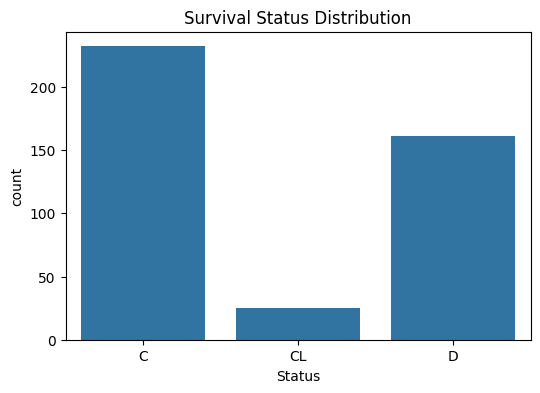

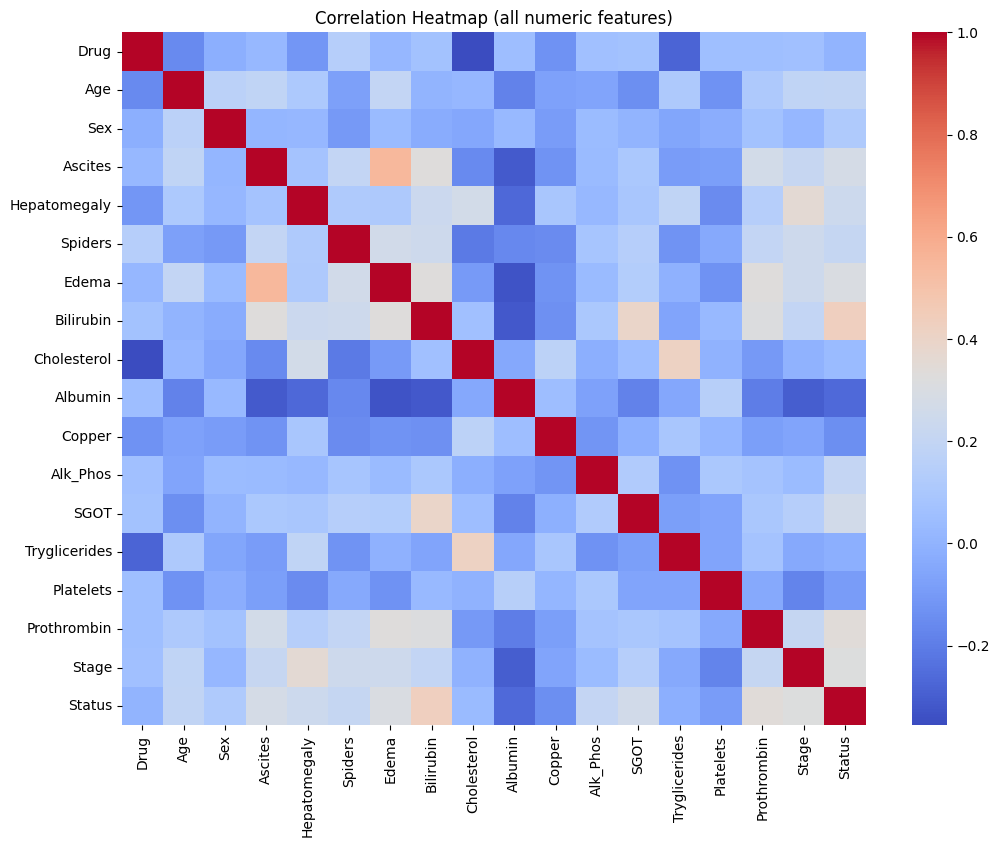

In [5]:
plt.figure(figsize=(6,4))
sns.countplot(x=target_col, data=df)
plt.xticks(range(len(class_names)), class_names)
plt.title('Survival Status Distribution')
plt.show()

plt.figure(figsize=(12,9))
corr = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, annot=False, cmap='coolwarm')
plt.title('Correlation Heatmap (all numeric features)')
plt.show()


In [6]:
feature_names = [c for c in df.columns if c != target_col]
X = df[feature_names].values
y = df[target_col].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))


Accuracy: 0.679

Classification Report:
              precision    recall  f1-score   support

           C       0.69      0.77      0.73        47
          CL       0.00      0.00      0.00         5
           D       0.68      0.66      0.67        32

    accuracy                           0.68        84
   macro avg       0.46      0.47      0.46        84
weighted avg       0.65      0.68      0.66        84



In [7]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

is_list = isinstance(shap_values, list)
n_classes = len(shap_values) if is_list else shap_values.shape[-1]
print(f"Number of classes explained: {n_classes}")
print(f"Class names: {class_names}")

# We'll focus on class 0 = 'D' (Death) as the class of primary clinical interest
focus_class = 0
sv = shap_values[focus_class] if is_list else shap_values[:, :, focus_class]
print(f"\nFocusing on class: '{class_names[focus_class]}' — shape: {sv.shape}")


Number of classes explained: 3
Class names: ['C', 'CL', 'D']

Focusing on class: 'C' — shape: (84, 17)


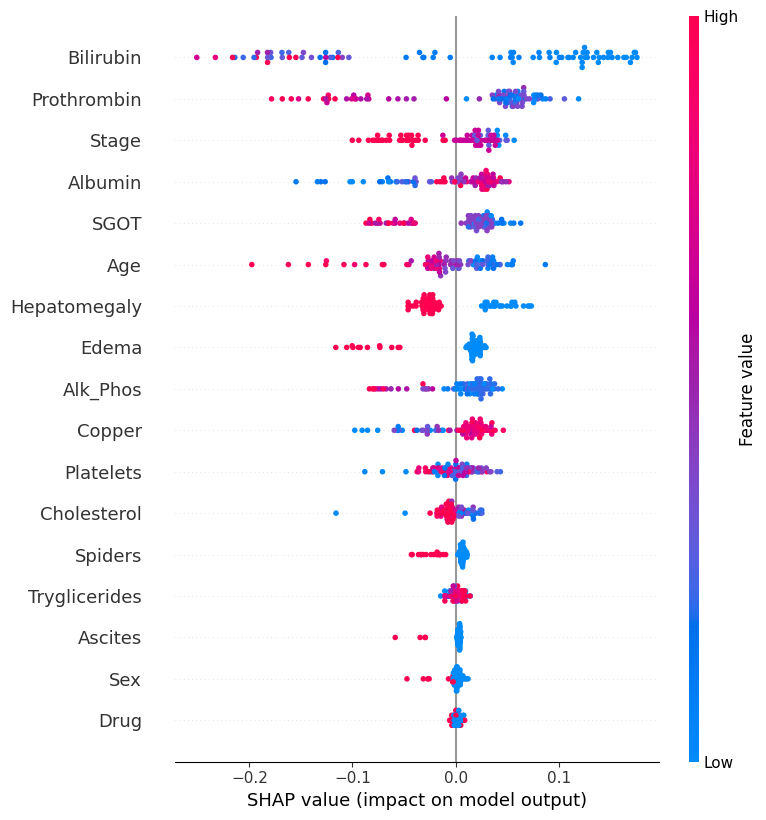

In [8]:
plt.figure()
shap.summary_plot(sv, X_test, feature_names=feature_names, show=False)
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()


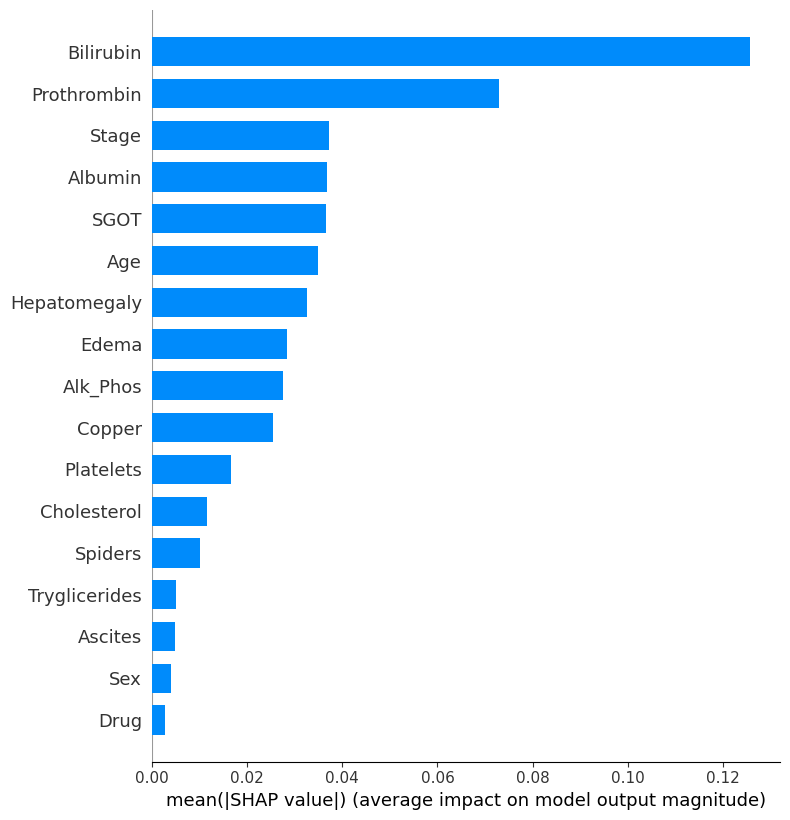

In [9]:
plt.figure()
shap.summary_plot(sv, X_test, feature_names=feature_names, plot_type='bar', show=False)
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()


Predicted probabilities: {'C': np.float64(0.3), 'CL': np.float64(0.02), 'D': np.float64(0.68)}
True label: D


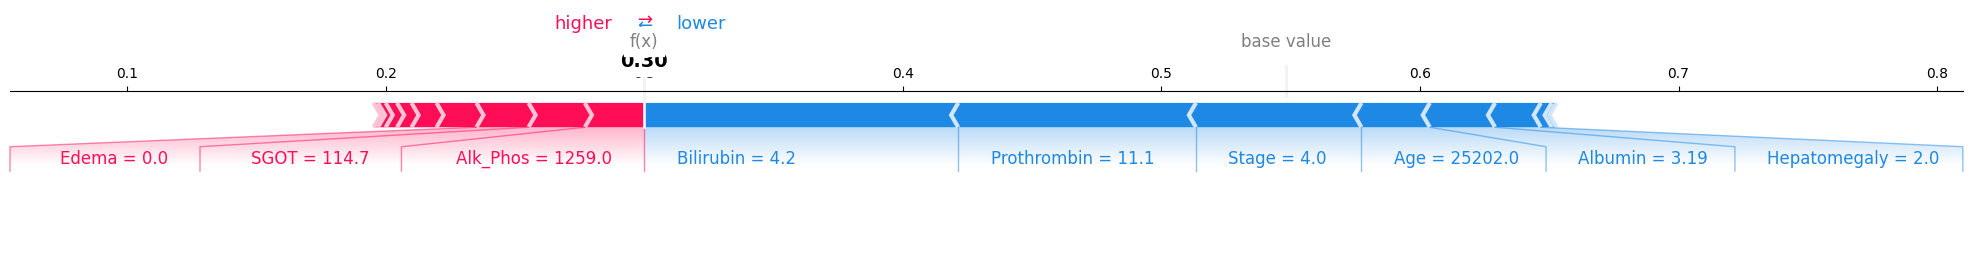

In [10]:
patient_idx = 0  # 👈 try changing this value (0 to len(X_test)-1)

pred_probs = model.predict_proba(X_test)[patient_idx]
print(f"Predicted probabilities: {dict(zip(class_names, np.round(pred_probs, 4)))}")
print(f"True label: {class_names[y_test[patient_idx]]}")

base_value = explainer.expected_value[focus_class] if is_list else explainer.expected_value[focus_class]
shap.force_plot(
    base_value, sv[patient_idx], X_test[patient_idx],
    feature_names=feature_names, matplotlib=True, show=False
)
plt.tight_layout()
plt.savefig('shap_force_patient0.png', dpi=150, bbox_inches='tight')
plt.show()


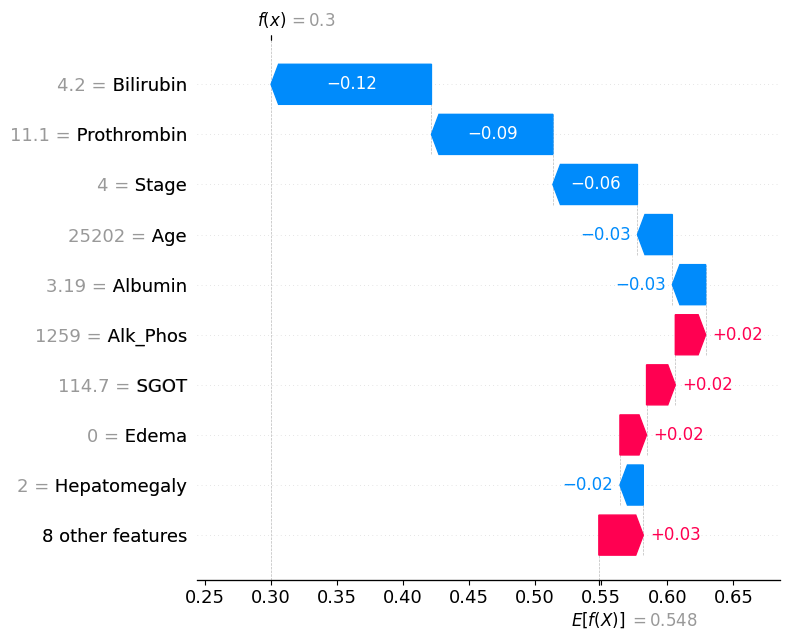

In [11]:
exp = shap.Explanation(
    values=sv[patient_idx],
    base_values=base_value,
    data=X_test[patient_idx],
    feature_names=feature_names
)
plt.figure()
shap.plots.waterfall(exp, show=False)
plt.tight_layout()
plt.show()


In [12]:
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    X_train,
    feature_names=feature_names,
    class_names=class_names,
    mode='classification',
    random_state=42
)
print("✅ LIME explainer ready!")


✅ LIME explainer ready!


In [13]:
lime_exp = lime_explainer.explain_instance(
    X_test[patient_idx],
    model.predict_proba,
    num_features=10,
    labels=[focus_class]
)

lime_exp.show_in_notebook(show_table=True)


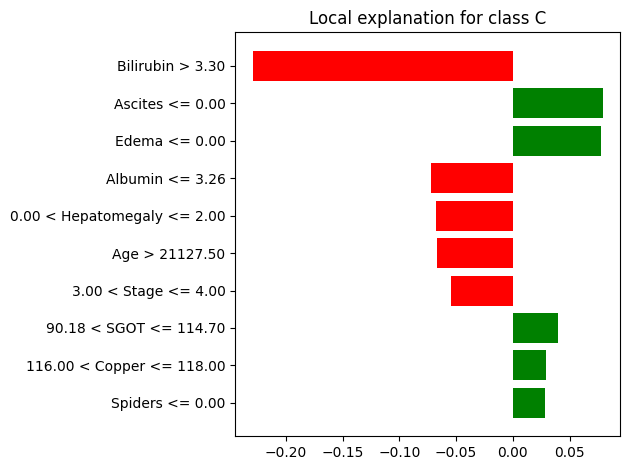

In [14]:
fig = lime_exp.as_pyplot_figure(label=focus_class)
plt.tight_layout()
plt.savefig('shap_vs_lime_patient0.png', dpi=150, bbox_inches='tight')
plt.show()


In [16]:
probs_death = model.predict_proba(X_test)[:, focus_class]
uncertainty = np.abs(probs_death - 0.5)
hardest_idx = np.argmin(uncertainty)

print(f"Most uncertain patient index: {hardest_idx}")
print(f"Predicted probability of Death: {probs_death[hardest_idx]:.4f}")
print(f"True label: {class_names[y_test[hardest_idx]]}")



Most uncertain patient index: 9
Predicted probability of Death: 0.5100
True label: D
